## Імпорти

In [1]:
import os
import io
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import librosa
import librosa.display
import soundfile as sf
import noisereduce as nr
import matplotlib.pyplot as plt
import speech_recognition as sr

from collections import Counter
from wordcloud import WordCloud
from deep_translator import GoogleTranslator
from gtts import gTTS
from pydub import AudioSegment
from pydub.playback import play


##  Налаштування

In [2]:
FILE_WAV = 'sample.wav' 

OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_RATE  = 16000  
MIC_DURATION = 30      
LANGUAGE     = 'uk-UA' 
TOP_N_WORDS  = 20      


## Завантаження аудіо



In [3]:

def load_from_file(path):
    '''
    Завантажує аудіофайл через librosa.
    '''
    print(f'Завантаження: {path}')
    signal, rate = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    print(f'Тривалість : {len(signal)/rate:.1f} с')
    print(f'Sample rate: {rate} Гц')
    print(f'Samples    : {signal.shape}')
    return signal, rate



def record_from_microphone(duration=MIC_DURATION):
    '''
    Записує аудіо з мікрофону через SpeechRecognition.
    Повертає numpy float32 array.
    '''
    recognizer = sr.Recognizer()
    print(f'Говоріть... (максимум {duration} с)')
    with sr.Microphone(sample_rate=SAMPLE_RATE) as source:
        recognizer.adjust_for_ambient_noise(source, duration=1)
        audio = recognizer.listen(source, timeout=duration,
                                   phrase_time_limit=duration)

    raw    = np.frombuffer(audio.get_wav_data(), dtype=np.int16)
    signal = raw.astype(np.float32) / 32768.0
    print(f'Записано: {len(signal)/SAMPLE_RATE:.1f} с')
    return signal, SAMPLE_RATE



signal, rate = load_from_file(FILE_WAV)      
# signal, rate = record_from_microphone()    

original_signal = signal.copy()

Завантаження: sample.wav
Тривалість : 213.6 с
Sample rate: 16000 Гц
Samples    : (3417216,)


## Аналіз вхідного сигналу 

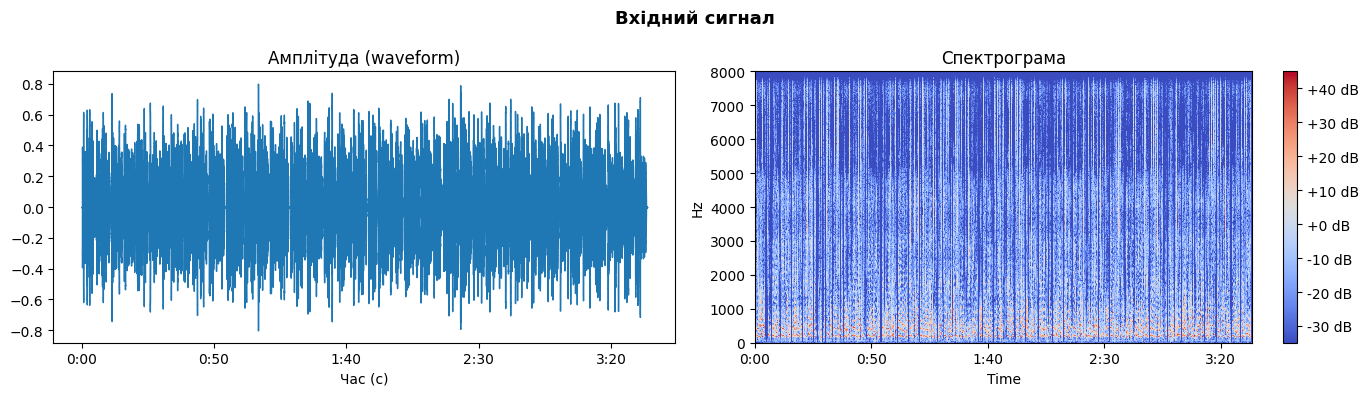

In [4]:
def plot_spectrogram(signal, rate, title='Спектрограма'):
   
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    
    librosa.display.waveshow(signal, sr=rate, ax=axes[0])
    axes[0].set_title('Амплітуда (waveform)')
    axes[0].set_xlabel('Час (с)')

    
    X   = librosa.stft(signal)
    Xdb = librosa.amplitude_to_db(abs(X))
    img = librosa.display.specshow(Xdb, sr=rate,
                                    x_axis='time', y_axis='hz',
                                    ax=axes[1])
    axes[1].set_title('Спектрограма')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()


plot_spectrogram(original_signal, rate, title='Вхідний сигнал')

## Фільтрація шумів

In [5]:
def audio_filter(signal, rate):

    print('Фільтрація шумів...')
    emphasized = librosa.effects.preemphasis(signal)
    cleaned = nr.reduce_noise(y=emphasized, sr=rate, stationary=False)
    cleaned = librosa.util.normalize(cleaned)

    return cleaned


cleaned_signal = audio_filter(original_signal, rate)


cleaned_path = os.path.join(OUTPUT_DIR, 'cleaned.wav')
sf.write(cleaned_path, cleaned_signal, rate)

Фільтрація шумів...
Очищений файл збережено: output/cleaned.wav


## Порівняння сигналів: до/після фільтрації

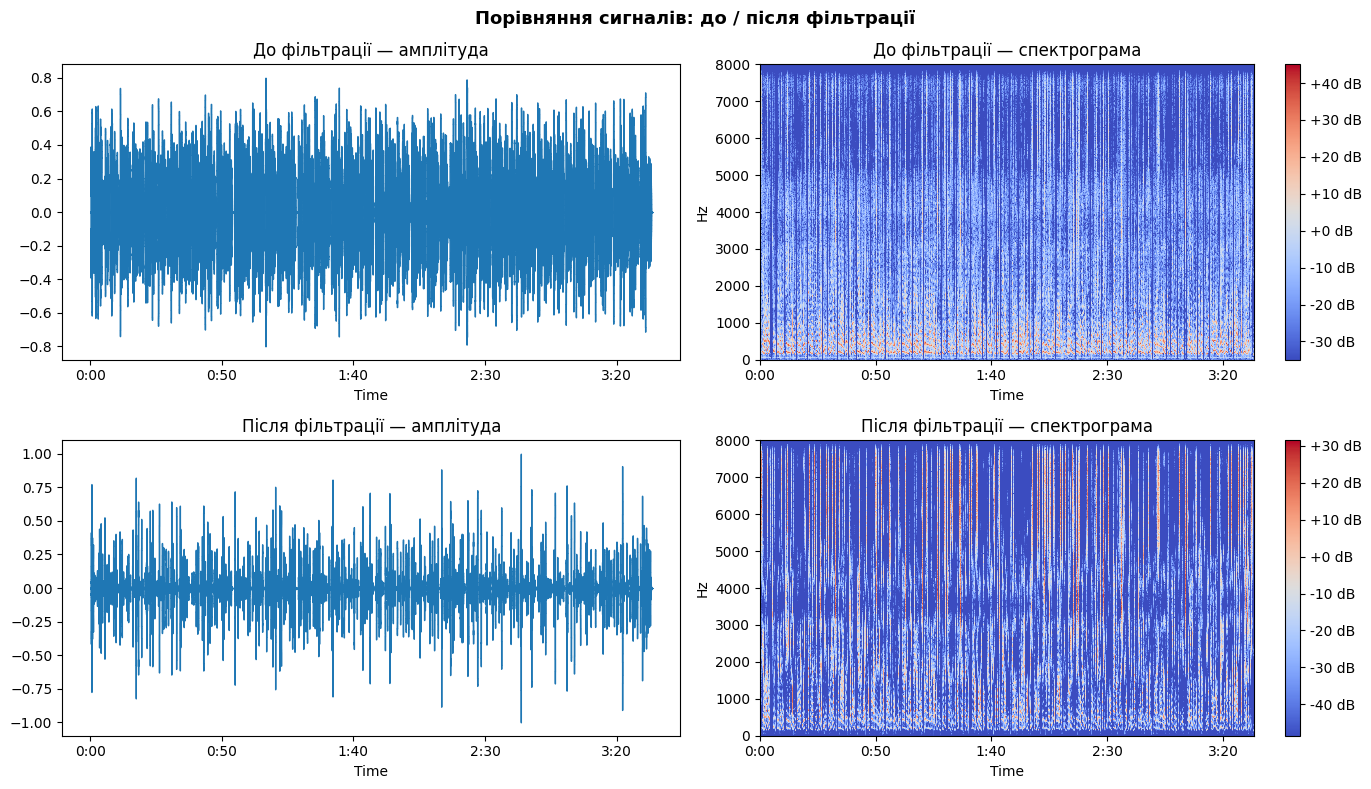

Графік збережено: output/signal_comparison.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Порівняння сигналів: до / після фільтрації',
             fontsize=13, fontweight='bold')

def draw_row(axes_row, sig, row_title):

    librosa.display.waveshow(sig, sr=rate, ax=axes_row[0])
    axes_row[0].set_title(f'{row_title} — амплітуда')

    X   = librosa.stft(sig)
    Xdb = librosa.amplitude_to_db(abs(X))
    img = librosa.display.specshow(Xdb, sr=rate,
                                    x_axis='time', y_axis='hz',
                                    ax=axes_row[1])
    axes_row[1].set_title(f'{row_title} — спектрограма')
    fig.colorbar(img, ax=axes_row[1], format='%+2.0f dB')

draw_row(axes[0], original_signal, 'До фільтрації')
draw_row(axes[1], cleaned_signal,  'Після фільтрації')

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'signal_comparison.png')
plt.savefig(path, dpi=150)
plt.show()


## Аудіо -> Текст


In [7]:
def convert_audio_to_text(signal, rate, language=LANGUAGE):
    
    buffer = io.BytesIO()
    sf.write(buffer, signal, rate, format='WAV')
    buffer.seek(0)

    recognizer = sr.Recognizer()
    with sr.AudioFile(buffer) as source:
        audio = recognizer.record(source)

    try:
        text = recognizer.recognize_google(audio, language=language)
        print('Розпізнано:', text)
    except sr.UnknownValueError:
        text = ''
        print('Не вдалося розпізнати мовлення.')
    except sr.RequestError as e:
        text = ''
        print(f'Помилка сервісу: {e}')

    return text


recognized_text = convert_audio_to_text(cleaned_signal, rate)
print(f'\nКількість слів: {len(recognized_text.split())}')

Розпізнано: у сучасному світі технології розвиваються з такою швидкістю що іноді здається ніби людина ледве встигає за цими змінами ще кілька десятиліть тому комп'ютери займали цілі кімнати а сьогодні вони поміщаються в кишені у вигляді смартфонів Інтернет став невід'ємною частиною повсякденного життя впливаючи на те як ми спілкуємося працюємо навчаємося і навіть відпочиваємо водночас із новими можливостями з'являються і нові виклики які потребують уважного осмислення однією з найбільших переваг технологічного прогресу є доступ до інформації сьогодні будь-яка людина може за лічені секунди знайти відповідь на складне питання прочитати наукову статтю або пройти онлайн курс від провідних університетів світу це відкриває безліч можливостей для саморозвитку та освіти незалежно від місця проживання чи фінансового становища проте водночас надлишок інформації може призводити до перевантаження та складнощів у визначенні достовірності джерел ще одним важливим аспектом є зміни на ринку праці авто

##  Збереження тексту у файл

In [8]:
from datetime import datetime

def save_text(text):
    '''
    Зберігає розпізнаний текст у текстовий файл.
    '''
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    path = os.path.join(OUTPUT_DIR, f'transcript_{timestamp}.txt')
    with open(path, 'w', encoding='utf-8') as f:
        f.write(text)
    print(f'Текст збережено: {path}')
    return path


text_path = save_text(recognized_text)


print('\n' + '─'*60)
print('РОЗПІЗНАНИЙ ТЕКСТ:')
print('─'*60)
print(recognized_text)
print('─'*60)

Текст збережено: output/transcript_20260421_182147.txt

────────────────────────────────────────────────────────────
РОЗПІЗНАНИЙ ТЕКСТ:
────────────────────────────────────────────────────────────
у сучасному світі технології розвиваються з такою швидкістю що іноді здається ніби людина ледве встигає за цими змінами ще кілька десятиліть тому комп'ютери займали цілі кімнати а сьогодні вони поміщаються в кишені у вигляді смартфонів Інтернет став невід'ємною частиною повсякденного життя впливаючи на те як ми спілкуємося працюємо навчаємося і навіть відпочиваємо водночас із новими можливостями з'являються і нові виклики які потребують уважного осмислення однією з найбільших переваг технологічного прогресу є доступ до інформації сьогодні будь-яка людина може за лічені секунди знайти відповідь на складне питання прочитати наукову статтю або пройти онлайн курс від провідних університетів світу це відкриває безліч можливостей для саморозвитку та освіти незалежно від місця проживання чи фінансов

## Верифікація


In [9]:
def text_to_speech_verification(text, play = False, lang='uk'):

    preview = text

    tts  = gTTS(text=preview, lang=lang, slow=False)
    path = os.path.join(OUTPUT_DIR, 'verification.mp3')
    tts.save(path)
    print(f'Аудіо верифікації збережено: {path}')

    print('Відтворення...')
    if (play):
        audio = AudioSegment.from_mp3(path)
        play(audio)

text_to_speech_verification(recognized_text)

Аудіо верифікації збережено: output/verification.mp3
Відтворення...


## Частотний аналіз тексту


Загальна кількість слів : 332
Унікальних слів         : 222

Топ-20 слів:
   1. технології              3 разів
   2. водночас                3 разів
   3. нові                    3 разів
   4. людина                  2 разів
   5. встигає                 2 разів
   6. сьогодні                2 разів
   7. частиною                2 разів
   8. виклики                 2 разів
   9. інформації              2 разів
  10. онлайн                  2 разів
  11. світу                   2 разів
  12. розвиток                2 разів
  13. саме                    2 разів
  14. стає                    2 разів
  15. створювати              2 разів
  16. можуть                  2 разів
  17. баланс                  2 разів
  18. технологій              2 разів
  19. сучасному               1 разів
  20. світі                   1 разів


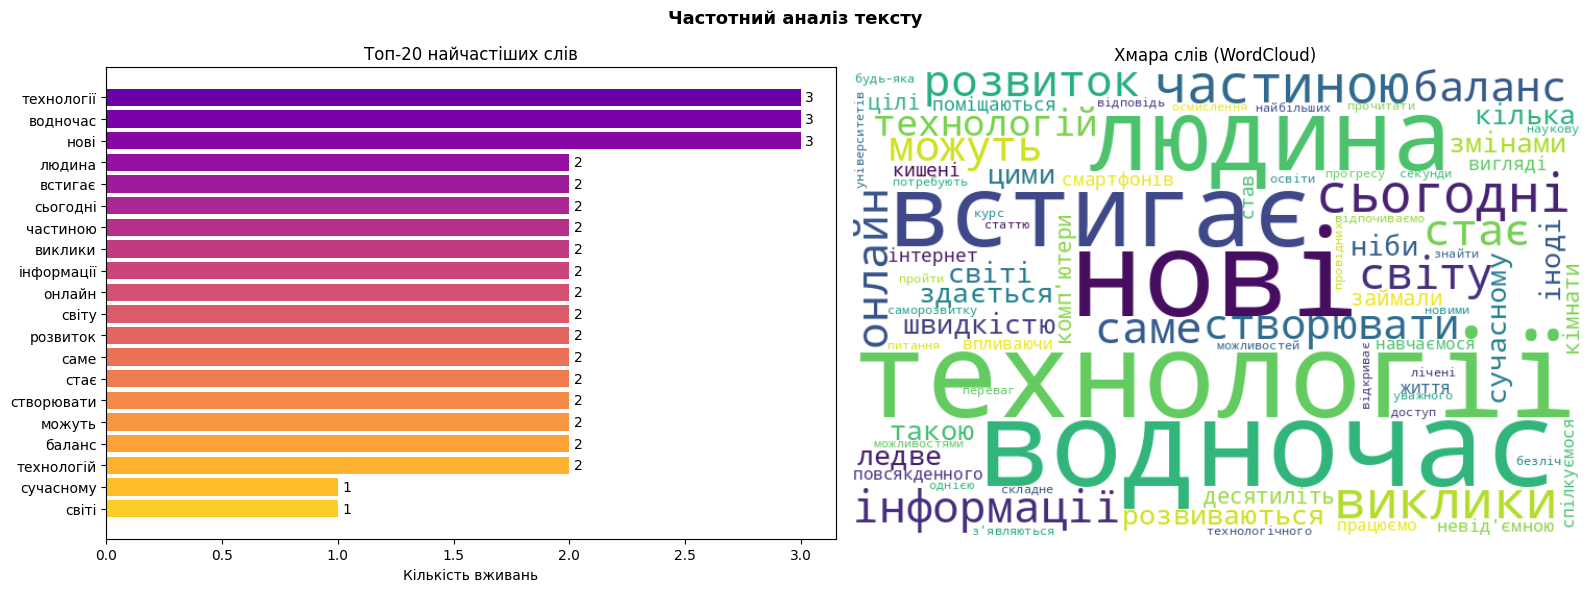


Графік збережено: output/frequency_analysis.png


In [10]:

UA_STOPWORDS = {
    'і', 'в', 'на', 'з', 'до', 'що', 'як', 'це', 'він', 'вона',
    'вони', 'ми', 'ви', 'я', 'та', 'але', 'або', 'не', 'бо',
    'за', 'по', 'від', 'про', 'для', 'при', 'під', 'над', 'між',
    'той', 'та', 'це', 'яка', 'який', 'яке', 'які', 'так', 'ще',
    'вже', 'де', 'коли', 'якщо', 'щоб', 'є', 'був', 'була',
    'були', 'буде', 'може', 'через', 'навіть', 'тому', 'також',
    'їх', 'ці', 'нас', 'їм', 'нам', 'його', 'її', 'ж', 'би',
}


def frequency_analysis(text, top_n=TOP_N_WORDS):

    
    words = [
        w.lower().strip('.,!?;:\'"()[]–—«»')
        for w in text.split()
        if len(w) > 2 and w.lower() not in UA_STOPWORDS
    ]

    counter   = Counter(words)
    total     = len(text.split())
    unique    = len(counter)
    top_words = counter.most_common(top_n)

    print(f'Загальна кількість слів : {total}')
    print(f'Унікальних слів         : {unique}')
    print(f'\nТоп-{top_n} слів:')
    for i, (word, count) in enumerate(top_words, 1):
        print(f'  {i:>2}. {word:<20} {count:>4} разів')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Частотний аналіз тексту', fontsize=13, fontweight='bold')

    labels = [w for w, _ in top_words]
    values = [c for _, c in top_words]
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(labels)))

    bars = ax1.barh(labels[::-1], values[::-1], color=colors[::-1])
    ax1.set_xlabel('Кількість вживань')
    ax1.set_title(f'Топ-{top_n} найчастіших слів')
    ax1.bar_label(bars, padding=3)

    wc = WordCloud(
        width=700, height=450,
        background_color='white',
        colormap='viridis',
        max_words=80,
    ).generate_from_frequencies(dict(counter.most_common(100)))

    ax2.imshow(wc, interpolation='bilinear')
    ax2.axis('off')
    ax2.set_title('Хмара слів (WordCloud)')

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, 'frequency_analysis.png')
    plt.savefig(path, dpi=150)
    plt.show()

    return counter


word_counter = frequency_analysis(recognized_text)

##  Анотація одною фразою 


In [15]:
def generate_annotation(text):
  
    from transformers import pipeline

 

    try:

        text_en = GoogleTranslator(source='uk', target='en').translate(text[:1000])

        summarizer = pipeline('summarization',
                              model='sshleifer/distilbart-cnn-12-6')
        result     = summarizer(text_en, max_length=60,
                                min_length=20, do_sample=False)
        summary_en = result[0]['summary_text']


        annotation = GoogleTranslator(source='en', target='uk').translate(summary_en)

    except Exception as e:
        print(f'  (summarizer недоступний: {e})')
        print('  Використовуємо запасний варіант — топ-5 слів')
        top5 = [w for w, _ in word_counter.most_common(5)]
        annotation = f'Текст про: {", ".join(top5)}.'

    print(f'\n Підсумок: {annotation}')
    return annotation


annotation = generate_annotation(recognized_text)

with open(text_path, 'a', encoding='utf-8') as f:
    f.write(f'\n\n--- АНОТАЦІЯ ---\n{annotation}\n')



 Підсумок: Кілька десятиліть тому комп’ютери займали цілі кімнати, а сьогодні вони поміщаються в кишені у вигляді смартфонів. Інтернет став невід’ємною частиною повсякденного життя, впливаючи на те, як ми спілкуємося, працюємо, навчаємось і відпочиваємо. Водночас з’являються нові можливості та нові виклики
